<a href="https://colab.research.google.com/github/YuriArduino/Estudos_Visao_Computacional/blob/OCR-E-OPENCV/Projeto_FInal_OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.  Preparando o ambiente

##1.1.   Instalando bibliotecas

In [ ]:
!pip install -q opencv-python pytesseract
!sudo apt install -q tesseract-ocr

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


##1.2. Importando DB

In [ ]:
! git clone https://github.com/sthemonica/text-recognize

Cloning into 'text-recognize'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 148 (delta 3), reused 1 (delta 1), pack-reused 144 (from 1)
Receiving objects: 100% (148/148), 37.21 MiB | 22.05 MiB/s, done.
Resolving deltas: 100% (35/35), done.


##1.3.  Importanto Bibliotecas

In [ ]:
import pytesseract
import numpy as np
import cv2
import re
import os
import matplotlib.pyplot as plt

from PIL import ImageFont, ImageDraw, Image
from pytesseract import Output
from google.colab.patches import cv2_imshow

fonte_dir = '/content/text-recognize/Imagens/calibri.ttf' # Explicitly defining fonte_dir

#1.4.  Importanto Idiomas

In [ ]:
!mkdir tessdata
!wget -O  ./tessdata/por.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
!wget -O  ./tessdata/eng.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/eng.traineddata?raw=true

--2025-11-08 04:20:13--  https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/tesseract-ocr/tessdata/raw/refs/heads/main/por.traineddata [following]
--2025-11-08 04:20:14--  https://github.com/tesseract-ocr/tessdata/raw/refs/heads/main/por.traineddata
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/tesseract-ocr/tessdata/refs/heads/main/por.traineddata [following]
--2025-11-08 04:20:14--  https://raw.githubusercontent.com/tesseract-ocr/tessdata/refs/heads/main/por.traineddata
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.1

In [ ]:
projeto = "/content/text-recognize/Imagens/Projeto"
caminho = [os.path.join(projeto, f) for f in os.listdir(projeto)]
print(caminho)

['/content/text-recognize/Imagens/Projeto/artigo-termos-ML.png', '/content/text-recognize/Imagens/Projeto/artigo-spark.png', '/content/text-recognize/Imagens/Projeto/artigo-eng-dados.png', '/content/text-recognize/Imagens/Projeto/artigo-desbalanceamento.png']


In [ ]:
def mostrar(img):
  fig = plt.gcf() # busca a figura atual
  fig.set_size_inches(20, 10) #define o tamanho
  plt.axis("off") #remove a visualização dos eixos
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) #faz a conversão de cores com o OpenCV
  plt.show() # mostra a imagem

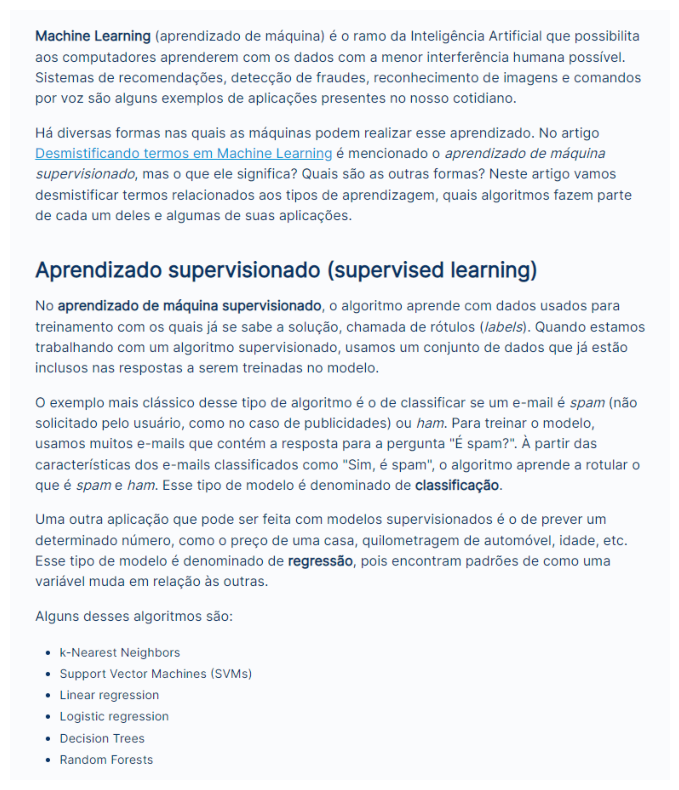

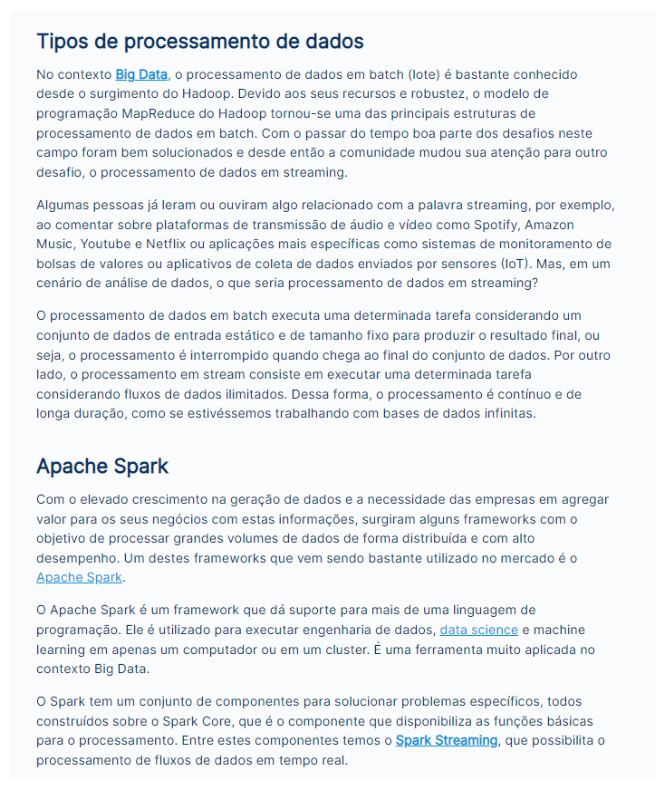

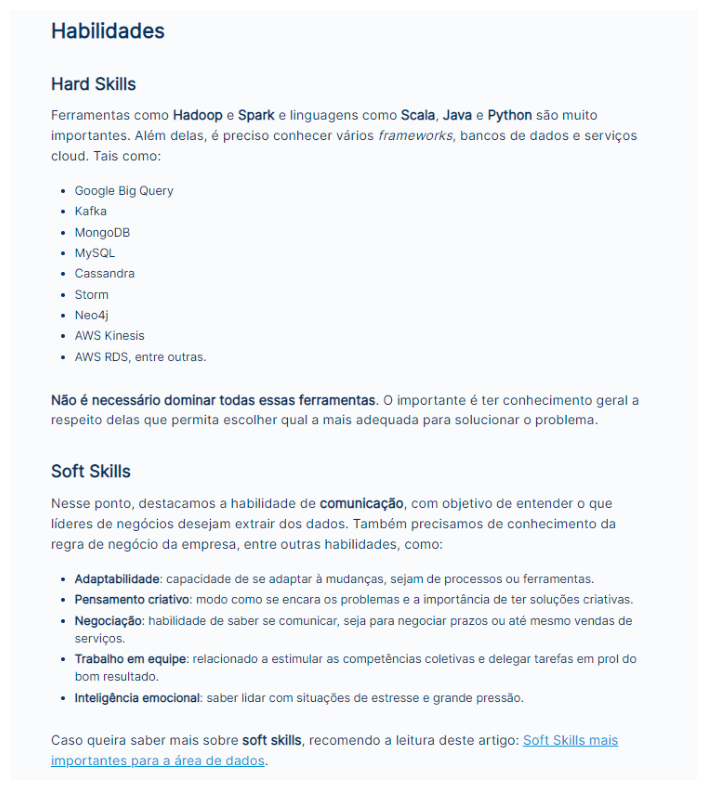

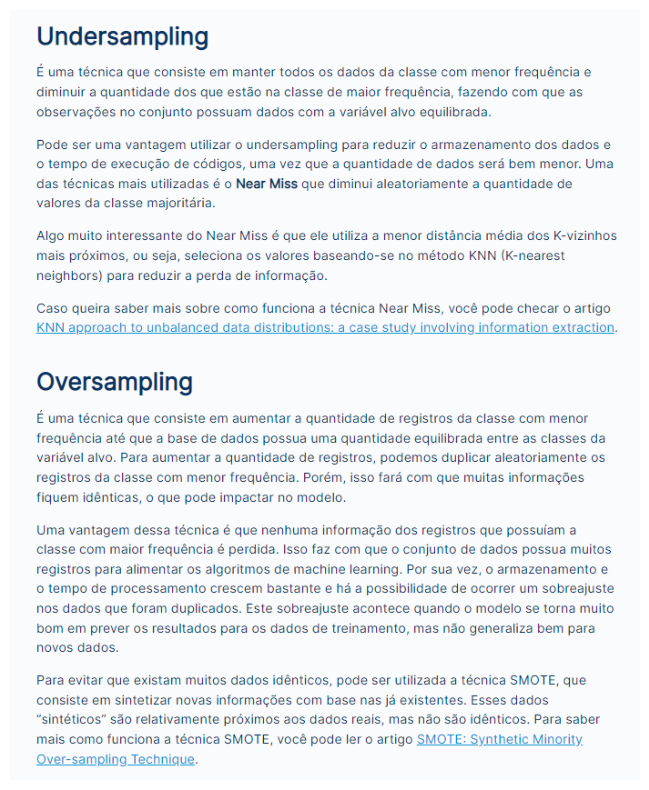

In [ ]:
for imagem in caminho:
  imagem = cv2.imread(imagem)
  mostrar(imagem)

#2.   Reconhecimento de texto

In [ ]:
config_tesseract = "--tessdata-dir tessdata"

def OCR_processa(img, config_tesseract):
  texto = pytesseract.image_to_string(img, lang='por', config=config_tesseract)
  return texto

In [ ]:
texto_completo = ''
nome_txt = 'resultados_ocr.txt'

In [ ]:
for imagem in caminho: # percorre as imagens no caminho
  img = cv2.imread(imagem)
  nome_imagem = os.path.split(imagem)[-1] ## recebe os nomes e diretórios das imagens, quebrados, precisamos apenas do -1 (última posição do diretório)
  nome_divisao = '===================\n' + str(nome_imagem) #divisão + nome da imagem que está sendo vista
  texto_completo = texto_completo + nome_divisao + '\n' # recebe o texto completo + a divisão + /n para pular a linha
  texto = OCR_processa(img, config_tesseract) #passa a imagem que vamos utilizar, no caso em cada imagem
  texto_completo = texto_completo + texto # concatena as duas variáveis

In [ ]:
texto_completo

'===================\nartigo-termos-ML.png\nMachine Learning (aprendizado de máquina) é o ramo da Inteligência Artificial que possibilita\naos computadores aprenderem com os dados com a menor interferência humana possível.\nSistemas de recomendações, detecção de fraudes, reconhecimento de imagens e comandos\npor voz são alguns exemplos de aplicações presentes no nosso cotidiano.\n\nHá diversas formas nas quais as máquinas podem realizar esse aprendizado. No artigo\nDesmistificando termos em Machine Learning é mencionado o aprendizado de máquina\nsupervisionado, mas o que ele significa? Quais são as outras formas? Neste artigo vamos\ndesmistificar termos relacionados aos tipos de aprendizagem, quais algoritmos fazem parte\nde cada um deles e algumas de suas aplicações.\n\nAprendizado supervisionado (supervised learning)\n\nNo aprendizado de máquina supervisionado, o algoritmo aprende com dados usados para\n\ntreinamento com os quais já se sabe a solução, chamada de rótulos (/abels). Qua

In [ ]:
## Salvando o arquivo em txt
arquivo_txt = open(nome_txt, 'w+') # a+ é para colocar no final do arquivo, w+ para sobre escrever o arquivo
arquivo_txt.write(texto_completo + '\n') #passa o texto que quer adicionar
arquivo_txt.close()

#3.  Busca de ocorrências

##3.1.  Nos  Textos

In [ ]:
termo_pesquisa = 'learning'

In [ ]:
with open(nome_txt) as f: # abre o documento txt
  ocorrencias = [i.start() for i in re.finditer(termo_pesquisa, f.read())] #ocorrencia é uma lista.
  #inicia-se em i e o termo re é de expressões regulares, o módulo finditer é para encontrar um termo de pesquisa dentro do arquivo
  #por isso os parâmetros são, respectivamente, termo_pesquisa e arquivo a ser lido.

In [ ]:
ocorrencias

[807, 4006, 7490]

##3.2  Na Listagem de Imagens

In [ ]:
for imagem in caminho:
  img = cv2.imread(imagem) #carrega a imagem
  nome_imagem = os.path.split(imagem)[-1] # passa a imagem e acessa a última posição do diretório
  print('====================\n' + str(nome_imagem)) # separação + nome da imagem

  texto = OCR_processa(img, config_tesseract) #usando o OCR

  ocorrencias = [i.start() for i in re.finditer(termo_pesquisa, texto)] #usando o finditer novamente no texto

  print('Número de ocorrências para o termo: {}: {}'.format(termo_pesquisa, len(ocorrencias)))
  #primeira chaves é para termo de pesquisa e a segunda é para ocorrencias
  print('\n')


artigo-termos-ML.png
Número de ocorrências para o termo: learning: 1


artigo-spark.png
Número de ocorrências para o termo: learning: 1


artigo-eng-dados.png
Número de ocorrências para o termo: learning: 0


artigo-desbalanceamento.png
Número de ocorrências para o termo: learning: 1




In [ ]:
imagem_treino = '/content/text-recognize/Atividades/Aula 5'
origem = [os.path.join(imagem_treino, f) for f in os.listdir(imagem_treino)]
print(origem)

['/content/text-recognize/Atividades/Aula 5/Aula5-Microstrategy.png', '/content/text-recognize/Atividades/Aula 5/Aula5-ROC.png', '/content/text-recognize/Atividades/Aula 5/Aula5-Visao.png', '/content/text-recognize/Atividades/Aula 5/Aula5-GitHub.png', '/content/text-recognize/Atividades/Aula 5/Aula5-Ambientes_Virtuais.png']


Aula5-Microstrategy.png


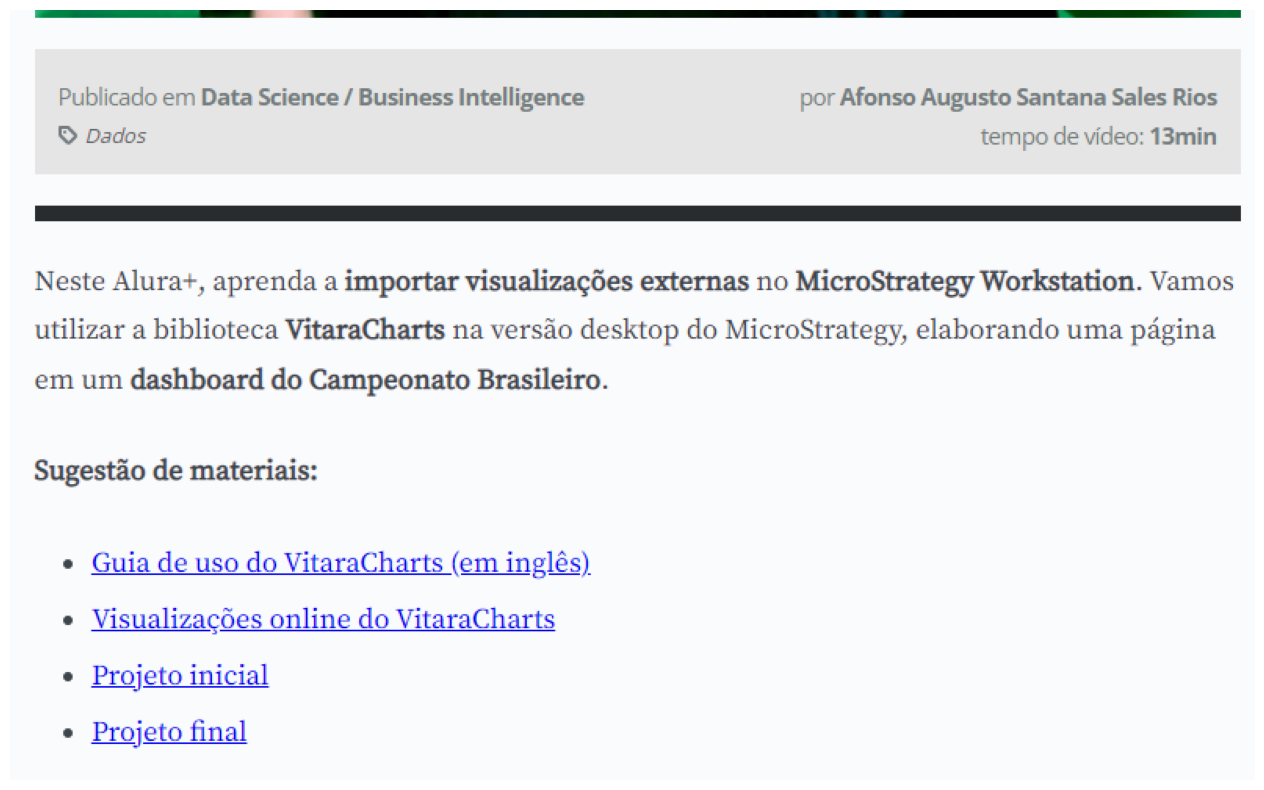

Aula5-ROC.png


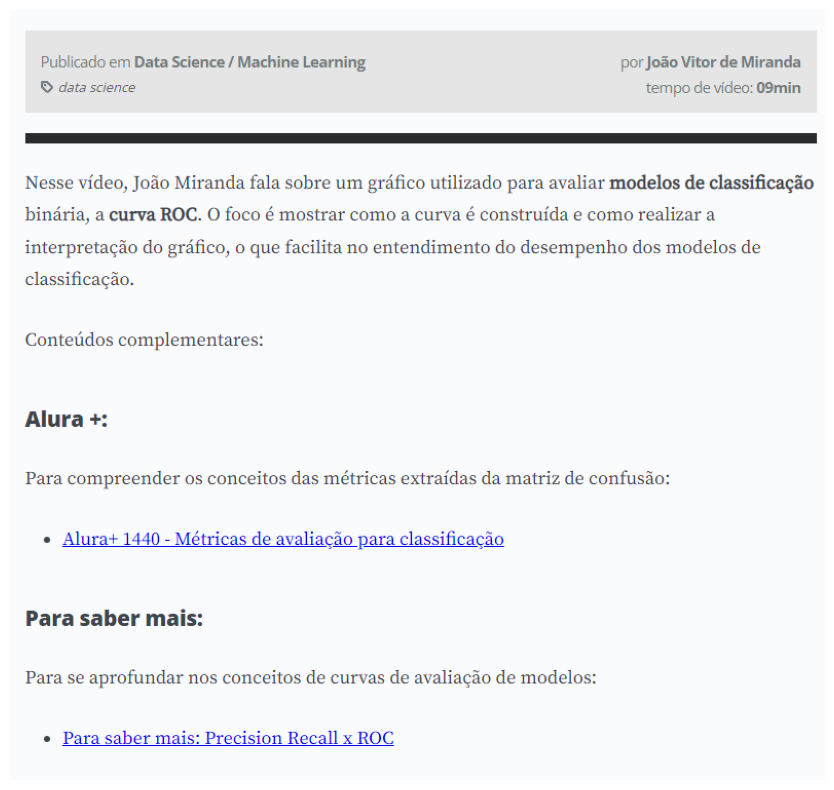

Aula5-Visao.png


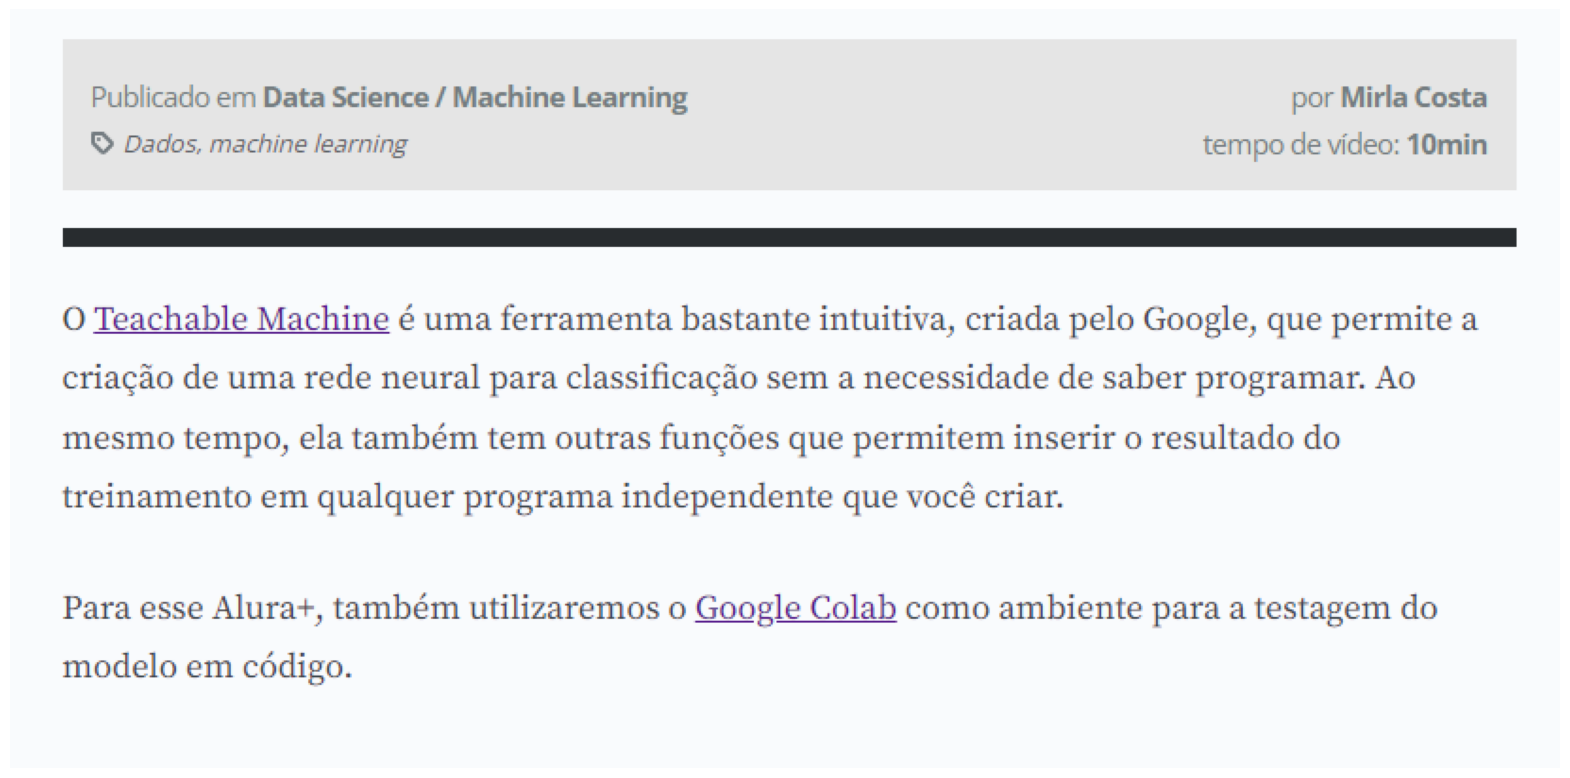

Aula5-GitHub.png


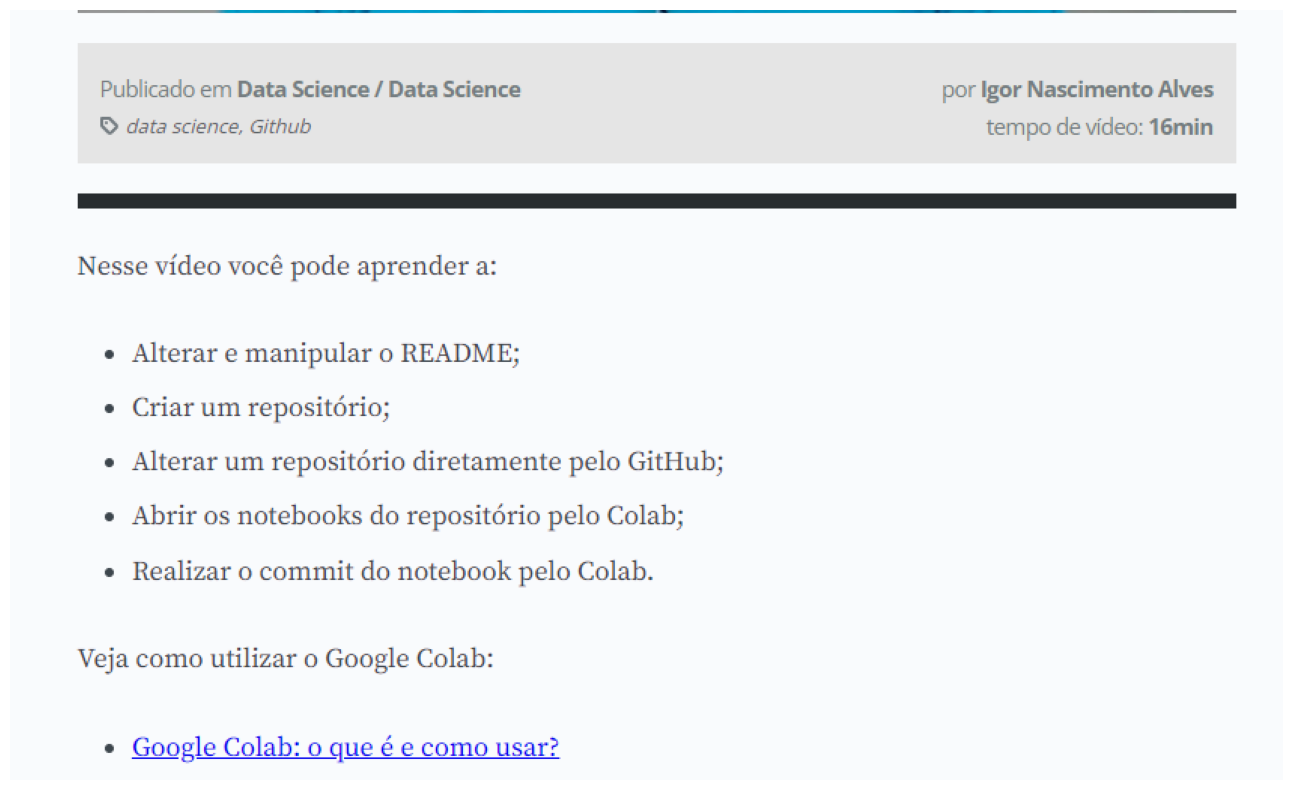

Aula5-Ambientes_Virtuais.png


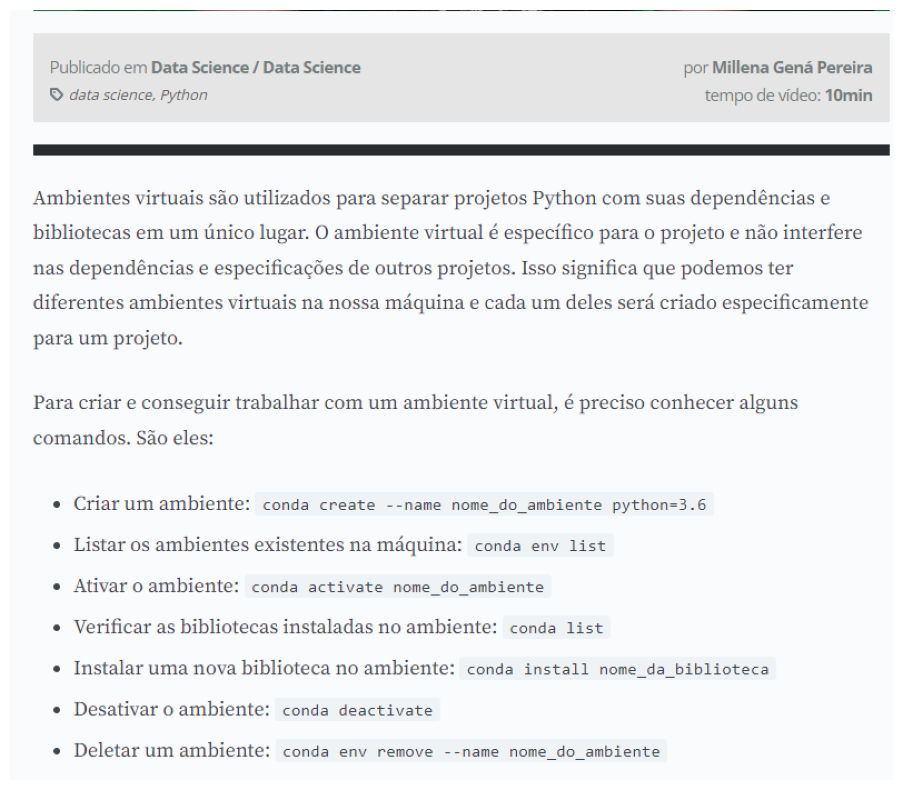

In [ ]:
for imagem in origem:
  img = cv2.imread(imagem) #carrega a imagem
  nome_imagem = os.path.split(imagem)[-1] # passa a imagem e acessa a última posição do diretório
  print('====================\n' + str(nome_imagem)) # separação + nome da imagem
  mostrar(img)

In [ ]:
texto_completo_2 = ''
nome_txt = 'resultados_ocr_exercicio.txt'

In [ ]:
for imagem in origem: # percorre as imagens no caminho
  img = cv2.imread(imagem)
  nome_imagem = os.path.split(imagem)[-1] ## recebe os nomes e diretórios das imagens, quebrados, precisamos apenas do -1 (última posição do diretório)
  nome_divisao = '===================\n' + str(nome_imagem) #divisão + nome da imagem que está sendo vista
  texto_completo_2 = texto_completo_2 + nome_divisao + '\n' # recebe o texto completo + a divisão + /n para pular a linha
  texto = OCR_processa(img, config_tesseract) #passa a imagem que vamos utilizar, no caso em cada imagem
  texto_completo_2 = texto_completo_2 + texto # concatena as duas variáveis

In [ ]:
texto_completo_2

"===================\nAula5-Microstrategy.png\nPublicado em Data Science / Business Intelligence por Afonso Augusto Santana Sales Rios\nO Dados tempo de vídeo: 13min\n\nNeste Alura+, aprenda a importar visualizações externas no MicroStrategy Workstation. Vamos\nutilizar a biblioteca VitaraCharts na versão desktop do MicroStrategy, elaborando uma página\nem um dashboard do Campeonato Brasileiro.\n\n  \n\nSugestão de materiai:\n\nGuia de uso do VitaraCharts (em inglês)\n\nVisualizações online do VitaraCharts\n\n \n\nProjet:\n\nProjeto final\n\x0c===================\nAula5-ROC.png\nPublicado em Data Science / Machine Learning porJoão Vitor de Miranda\nE data science tempo de vídeo: 09min\n\nNesse vídeo, João Miranda fala sobre um gráfico utilizado para avaliar modelos de classificação\nbinária, a curva ROC. O foco é mostrar como a curva é construída e como realizar a\ninterpretação do gráfico, o que facílita no entendimento do desempenho dos modelos de\n\nclassificação.\n\nConteúdos compl

In [ ]:
## Salvando o arquivo em txt
arquivo_txt = open(nome_txt, 'w+') # a+ é para colocar no final do arquivo, w+ para sobre escrever o arquivo
arquivo_txt.write(texto_completo_2 + '\n') #passa o texto que quer adicionar
arquivo_txt.close()

In [ ]:
termo_pesquisa = 'ambiente'

In [ ]:
with open(nome_txt) as f: # abre o documento txt
  ocorrencias = [i.start() for i in re.finditer(termo_pesquisa, f.read())] #ocorrencia é uma lista.
  #inicia-se em i e o termo re é de expressões regulares, o módulo finditer é para encontrar um termo de pesquisa dentro do arquivo
  #por isso os parâmetros são, respectivamente, termo_pesquisa e arquivo a ser lido.

In [ ]:
print (f"A palavra {termo_pesquisa} foi encontrada {len(ocorrencias)} vezes, nas posições:")
print ()
for i in range(0, len(ocorrencias), 3):
    print(ocorrencias[i:i+3])

A palavra ambiente foi encontrada 14 vezes, nas posições:

[1777, 2567, 2724]
[2863, 2945, 2983]
[3013, 3072, 3105]
[3156, 3212, 3269]
[3310, 3352]


In [ ]:
for imagem in origem:
  img = cv2.imread(imagem) #carrega a imagem
  nome_imagem = os.path.split(imagem)[-1] # passa a imagem e acessa a última posição do diretório
  print('====================\n' + str(nome_imagem)) # separação + nome da imagem

  texto = OCR_processa(img, config_tesseract) #usando o OCR

  ocorrencias = [i.start() for i in re.finditer(termo_pesquisa, texto)] #usando o finditer novamente no texto

  print('Número de ocorrências para o termo: {}: {}'.format(termo_pesquisa, len(ocorrencias)))
  #primeira chaves é para termo de pesquisa e a segunda é para ocorrencias
  print('\n')


Aula5-Microstrategy.png
Número de ocorrências para o termo: ambiente: 0


Aula5-ROC.png
Número de ocorrências para o termo: ambiente: 0


Aula5-Visao.png
Número de ocorrências para o termo: ambiente: 1


Aula5-GitHub.png
Número de ocorrências para o termo: ambiente: 0


Aula5-Ambientes_Virtuais.png
Número de ocorrências para o termo: ambiente: 13




#4.  Reconhecimento na imagem

In [ ]:
class OCR:
  def __init__(
      self,
      config_tesseract="--tessdata-dir tessdata",
      fonte_dir='/content/text-recognize/Imagens/calibri.ttf'
  ):
    self.config_tesseract = config_tesseract
    self.fonte_dir = fonte_dir

  def process_image(self, img, lang='por'):
    """Processes an image to extract text and bounding box data."""
    resultado = pytesseract.image_to_data(img, lang=lang, config=self.config_tesseract, output_type=Output.DICT)
    texto = pytesseract.image_to_string(img, lang=lang, config=self.config_tesseract)
    return texto, resultado

  @staticmethod
  def escreve_texto(
      texto,
      x,
      y,
      img,
      fonte_dir,
      cor=(50, 50, 255),
      tamanho=16
      ):
    fonte = ImageFont.truetype(
        fonte_dir,
        tamanho
        )

    img_pil = Image.fromarray(img)
    draw = ImageDraw.Draw(img_pil)
    draw.text(
        (x, y-tamanho),
        texto,
        font = fonte,
        fill = cor)

    img = np.array(img_pil)

    return img

  @staticmethod
  def caixa_texto(
      i,
      resultado,
      img,
      cor=(255, 100, 0)
      ):

    x = resultado["left"][i]
    y = resultado["top"][i]
    w = resultado["width"][i]
    h = resultado["height"][i]

    cv2.rectangle(img, (x, y), (x + w, y + h), cor, 2)

    return x, y, img

  def find_and_draw_text(self, img, termo_pesquisa, min_conf):
    resultado = pytesseract.image_to_data(img, config=self.config_tesseract, lang='por', output_type=Output.DICT)
    num_ocorrencias = 0

    for i in range(0, len(resultado['text'])):
      confianca = int(resultado['conf'][i])
      if confianca > min_conf:
        texto = str(resultado['text'][i]) # Ensure text is a string before calling .lower()
        if termo_pesquisa.lower() in texto.lower(): # Changed this line for case-insensitive search
          x, y, img = OCR.caixa_texto(i, resultado, img, (0,0,255))
          img = OCR.escreve_texto(texto, x, y, img, self.fonte_dir, (50,50,225), 14)

          num_ocorrencias += 1
    return img, num_ocorrencias

In [ ]:
min_conf = 30  #@param {type:"slider", min:0, max:100}

In [ ]:
ocr_instance = OCR(config_tesseract=config_tesseract, fonte_dir=fonte_dir)

def OCR_processa_imagem(img, termo_pesquisa, config_tesseract, min_conf):
  img_result, num_ocorrencias = ocr_instance.find_and_draw_text(img, termo_pesquisa, min_conf)
  return img_result, num_ocorrencias

artigo-termos-ML.png
Número de ocorrências para learning em artigo-termos-ML.png: 3




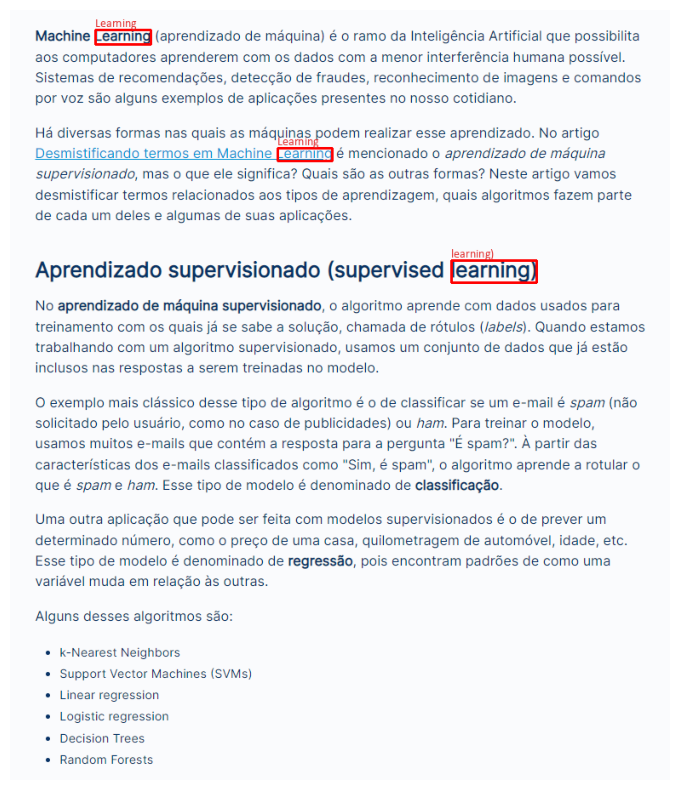

artigo-spark.png
Número de ocorrências para learning em artigo-spark.png: 1




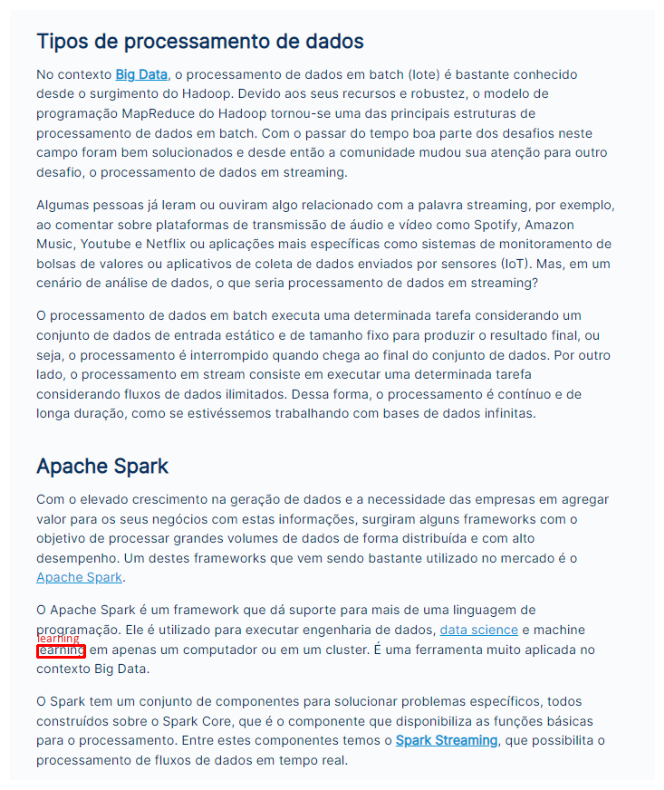

artigo-eng-dados.png
Número de ocorrências para learning em artigo-eng-dados.png: 0




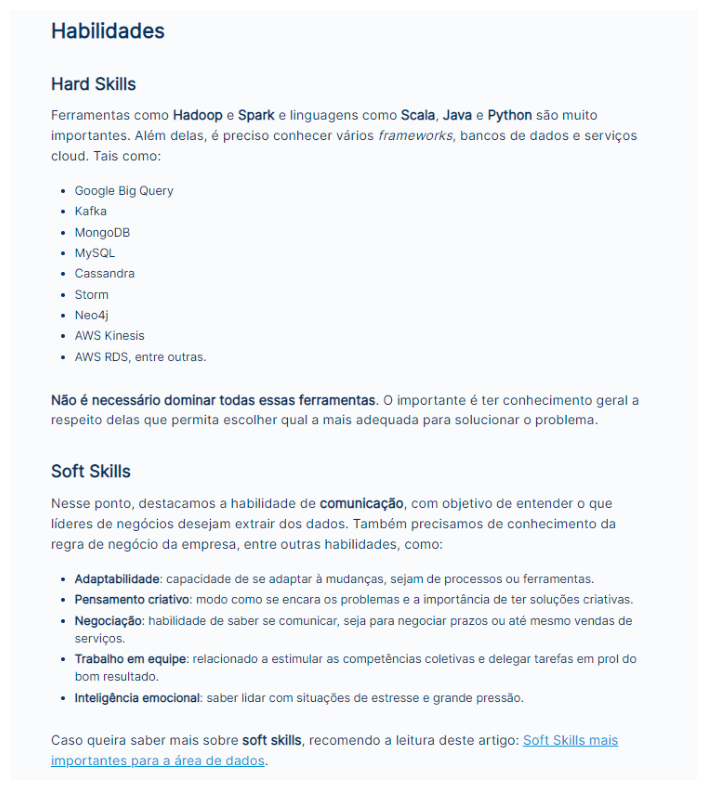

artigo-desbalanceamento.png
Número de ocorrências para learning em artigo-desbalanceamento.png: 1




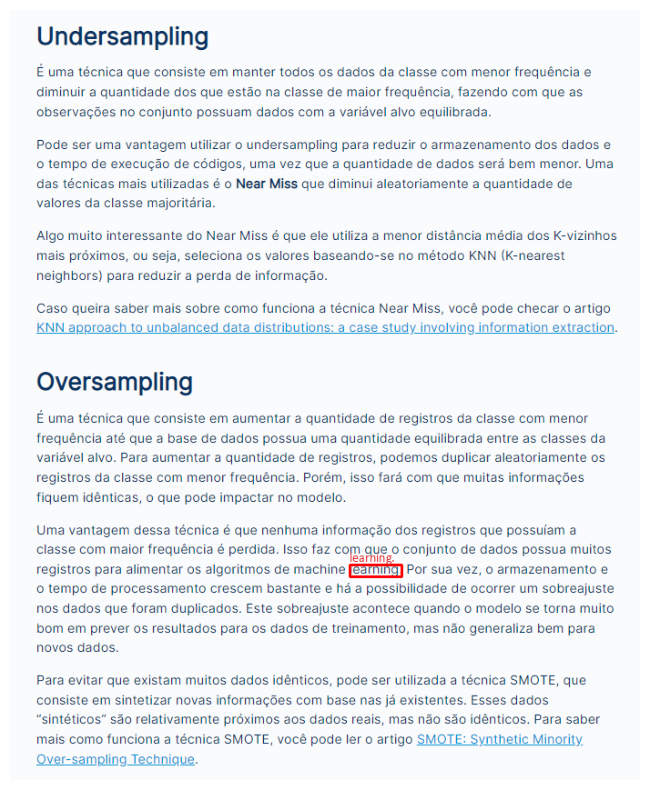

In [ ]:
termo_pesquisa = 'learning'

for imagem in caminho:
  img = cv2.imread(imagem) #carrega a imagem
  img_original = img.copy() #cria uma cópia da imagem para não escrever em cima da original

  nome_imagem = os.path.split(imagem)[-1] # passa a imagem e acessa a última posição do diretório
  print('===================\n' + str(nome_imagem))  # separação + nome da imagem

  img, numero_ocorrencias = OCR_processa_imagem(img, termo_pesquisa, config_tesseract, min_conf) #usando o OCR_processa_imagem
  print('Número de ocorrências para {} em {}: {}'.format(termo_pesquisa, nome_imagem, numero_ocorrencias))
    #primeira chaves é para termo de pesquisa e a segunda nome das imagens e a terceira é o numeros de ocorrencias
  print('\n')

  mostrar(img)